# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [4]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can we predict an NBA player's points scored in their next game based on their recent performance stats and game context?

**This is a prediction (umbrella) problem because:** We are forecasting a future outcome (next game points) from historical data, not trying to explain what causes scoring.

**The decision this enables:** This analysis would help a sports bettor decide whether to bet the over or under on a player's points prop line on a given night.

**Dataset:** NBA Player Game Logs 2023-24 Season 
- **Source:** nba_api (URL: https://github.com/swar/nba_api)
- **N =** 30,398 player-game observations
- **Features =** 70 columns including points, rebounds, assists, minutes, FG%, 3P%, plus/minus, matchup, and game date
- **Target variable =** PTS (points scored in the game)
- **Access date:** April 16, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [5]:
!pip install nba_api -q

from nba_api.stats.endpoints import playergamelogs
import pandas as pd
import time

# 23-24 season
logs = playergamelogs.PlayerGameLogs(season_nullable='2023-24')
df = logs.get_data_frames()[0]

print(df.shape)
print(df.columns.tolist())
df.head()


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
(30398, 70)
['SEASON_YEAR', 'PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK', 'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'AVAILABLE_FLAG', 'MIN_SEC', 'TEAM_COUNT']


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT
0,2023-24,1628369,Jayson Tatum,Jayson,1610612738,BOS,Boston Celtics,0042300405,2024-06-17T00:00:00,BOS vs. DAL,...,1006,831,1772,390,1,150,612,1,44:57,1
1,2023-24,1629029,Luka Dončić,Luka,1610612742,DAL,Dallas Mavericks,0042300405,2024-06-17T00:00:00,DAL @ BOS,...,1006,1386,28796,1148,1,150,779,1,43:23,1
2,2023-24,1627759,Jaylen Brown,Jaylen,1610612738,BOS,Boston Celtics,0042300405,2024-06-17T00:00:00,BOS vs. DAL,...,1006,3722,1324,2385,2447,150,2734,1,44:15,1
3,2023-24,201950,Jrue Holiday,Jrue,1610612738,BOS,Boston Celtics,0042300405,2024-06-17T00:00:00,BOS vs. DAL,...,20170,7477,1145,5451,1,150,5621,1,43:08,1
4,2023-24,1628401,Derrick White,Derrick,1610612738,BOS,Boston Celtics,0042300405,2024-06-17T00:00:00,BOS vs. DAL,...,7887,8348,13131,6835,2447,150,5621,1,38:08,1


### 2.2 Basic Description

In [6]:
# ============================================================
# 2.2 Describe your data
# ============================================================

# Basic info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

# Detailed info + summary stats
print("\n--- df.info() ---")
df.info()

print("\n--- df.describe() ---")
display(df.describe())

Shape: (30398, 70)

Columns:
 ['SEASON_YEAR', 'PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK', 'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'AVAILABLE_FLAG', 'MIN_SEC', 'TEAM_COUNT']

Data Types:
 SEASON_YEAR                str
PLAYER_ID                int64
PLAYER_NAME                str
NICKNAME                   str
TEAM_ID         

,PLAYER_ID,TEAM_ID,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,...,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,AVAILABLE_FLAG,TEAM_COUNT
count,3.039800e+04,3.039800e+04,30398.000000,30398.000000,30398.000000,30398.000000,30398.000000,30398.000000,30398.000000,30398.000000,...,30398.000000,30398.000000,30398.000000,30398.000000,30398.000000,30398.000000,30398.000000,30398.000000,30398.000000,30398.0
mean,2.182530e+06,1.604679e+09,22.144500,3.845582,8.140536,0.433224,1.172051,3.227778,0.262431,1.559379,...,12093.018587,11937.929173,14460.937595,14808.577143,15140.789723,2250.180604,149.269656,14867.332818,1.003224,1.0
std,1.288129e+07,9.758335e+07,11.138737,3.316388,6.135704,0.259211,1.474974,3.024322,0.293152,2.269229,...,9394.957910,6865.006148,8317.646860,8766.472728,8723.774184,665.354741,10.406317,8669.123399,0.056689,0.0
min,2.544000e+03,1.231500e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
25%,1.626196e+06,1.610613e+09,13.816667,1.000000,3.000000,0.286000,0.000000,1.000000,0.000000,0.000000,...,7242.000000,4874.000000,7477.000000,7235.000000,7565.000000,2447.000000,150.000000,7576.000000,1.000000,1.0
50%,1.629614e+06,1.610613e+09,22.733333,3.000000,7.000000,0.455000,1.000000,3.000000,0.200000,1.000000,...,15164.000000,12768.000000,15155.000000,14297.000000,15150.000000,2447.000000,150.000000,14915.000000,1.000000,1.0
75%,1.630572e+06,1.610613e+09,31.266667,6.000000,12.000000,0.583000,2.000000,5.000000,0.500000,2.000000,...,21868.000000,20170.000000,22563.000000,22186.000000,22756.000000,2447.000000,150.000000,22316.000000,1.000000,1.0
max,1.962948e+08,1.610617e+09,53.950000,25.000000,47.000000,1.000000,12.000000,23.000000,1.000000,24.000000,...,30131.000000,20170.000000,26568.000000,30398.000000,30398.000000,2447.000000,150.000000,29121.000000,2.000000,1.0


### 2.3 Missing Data Assessment

Missing Data (%):
 MATCHUP              0.002105
TEAM_ABBREVIATION    0.002105
TEAM_NAME            0.002105
dtype: float64


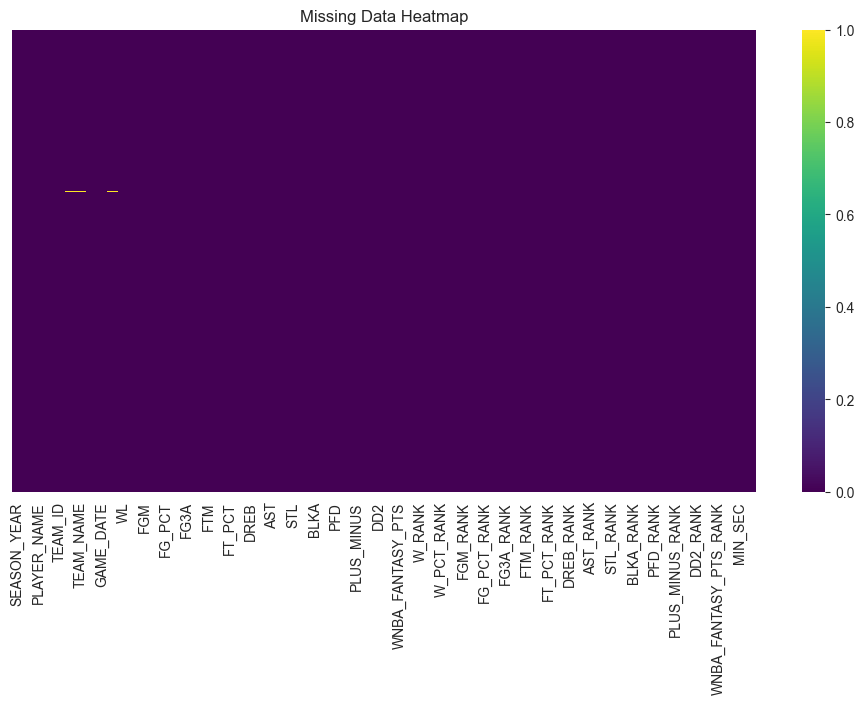

In [7]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

# Missing percentage per column
missing_pct = df.isnull().mean().sort_values(ascending=False)

# Print only columns with missing values
missing_pct = missing_pct[missing_pct > 0]
print("Missing Data (%):\n", missing_pct)

# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()


**Missing data strategy:** MAR — missingness likely tied to game context (e.g., DNPs, zero minutes, or role-based stats); I will drop rows with no playing time for modeling, impute minor missing values with median where appropriate, and optionally add indicator flags for key variables. 

### 2.4 Distribution Plots

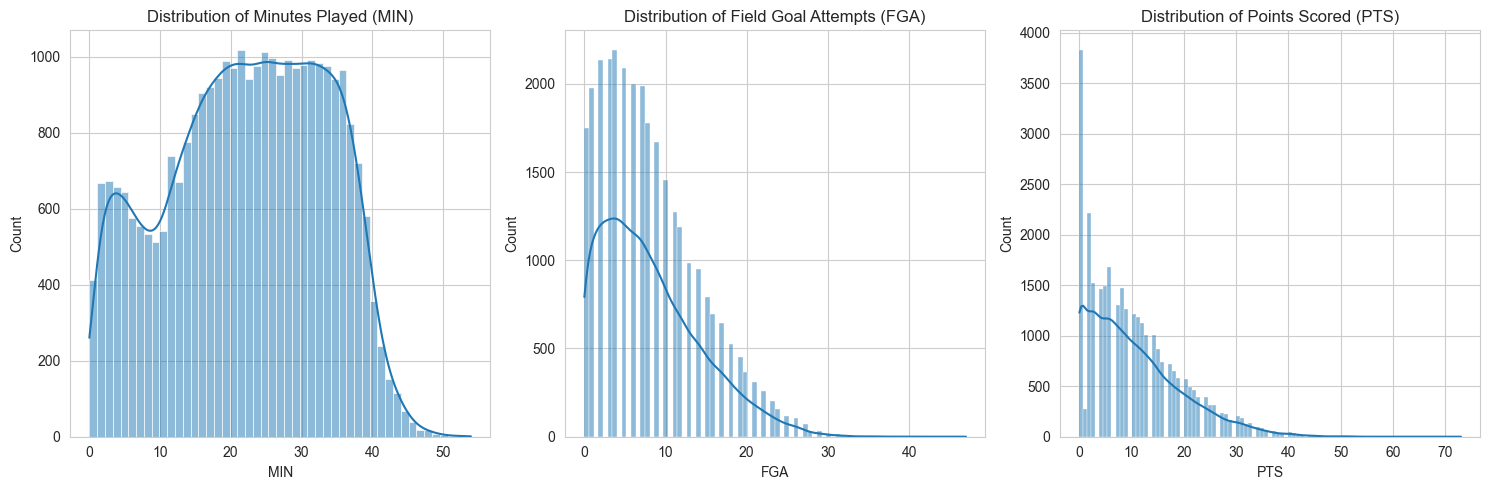

In [8]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['MIN'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Minutes Played (MIN)')

sns.histplot(df['FGA'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Field Goal Attempts (FGA)')

sns.histplot(df['PTS'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Points Scored (PTS)')

plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [9]:
# ============================================================
# 2.5 Outlier check (Ch 4)
# ============================================================

def tukey_fences(series, k=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

for col in ['PTS', 'MIN', 'FGA']:
    lower, upper = tukey_fences(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

PTS: 568 outliers (1.9%)
MIN: 0 outliers (0.0%)
FGA: 309 outliers (1.0%)


**Outlier strategy:** I will keep the outliers. Extreme scoring games are real events not data errors. Winsorizing would remove legitimate signal for  a sports bettor trying to predict breakout performances.

### 2.6 Correlations

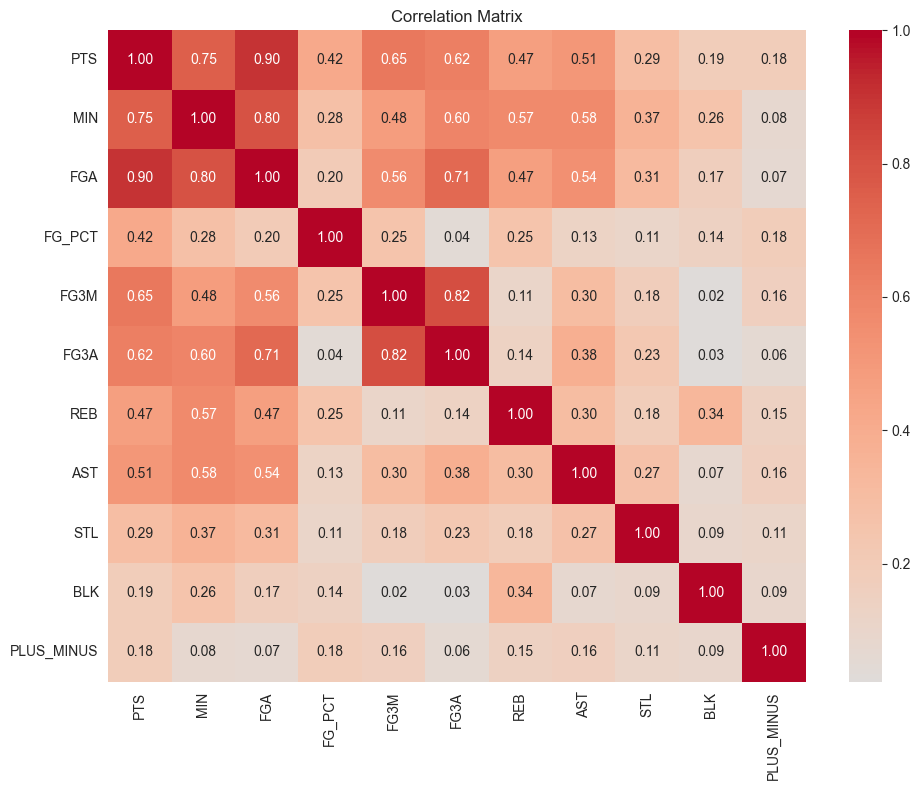

In [10]:
# ============================================================
# 2.6 Correlation heatmap (Ch 5)
# ============================================================

numeric_cols = ['PTS', 'MIN', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'REB', 'AST', 'STL', 'BLK', 'PLUS_MINUS']
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   PTS is right-skewed with most players scoring between 0 and 15 points and a long tail of high-scoring games. This is a regression problem so balance does not apply, but the skew means I will monitor whether log-transforming PTS improves model performance

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   FGA (0.90) and MIN (0.75) are the strongest predictors of PTS. FGA  and FG3A are highly correlated with each other at 0.82, which is multicollinearity I will address by dropping FG3A and keeping FGA as the more general feature.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   The biggest issue is DNP rows where players logged 0 minutes, which creates misleading low-point observations that are not true game performances. I will drop all rows where MIN equals 0 before modeling.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 30,398** observations and **M = 70** features.

**Missing data:** Less than 0.1% of cells are missing. The missingness  pattern appears to be MAR because missingness is tied to game context such as DNPs and role-based ranking stats that only appear for players who ranked high enough. I will handle missing data by dropping rows with zero minutes played and dropping ranking columns entirely.

**Outliers:** I identified 568 outliers in PTS and 309 in FGA using Tukey Fences. I will handle them by keeping them since very high scoring games are real events and not data errors.


**Target variable:** PTS is right-skewed with most of the observations being between 0 and 15 points and a long tail extending to 70+, consistent with the NBA scoring distribution where most players are average and only stars regularly score above 30.

**Key finding from EDA:** FGA is the single strongest predictor of PTS with a correlation of 0.90, and minutes played (MIN) follows at 0.75, confirming that usage and opportunity are the primary drivers of scoring output.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [11]:
# ============================================================
# 3.1 Train/Test Split
# ============================================================

# Drop rows where MIN == 0
df = df[df['MIN'] != 0]

# Define features and target
X = df[['MIN', 'FGA', 'FG_PCT', 'FG3M', 'REB', 'AST', 'STL', 'BLK', 'PLUS_MINUS']]
y = df['PTS']

# For regression: remove stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 24316 samples
Test:  6079 samples


### 3.2 Model 1: Baseline

In [12]:
# ============================================================
# 3.2 Baseline Model (Linear Regression)
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model_1 = LinearRegression()
model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)

# Regression metrics
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_1):.4f}')

RMSE: 2.8913
MAE:  2.1931
R2:   0.8936


### 3.3 Model 2: Your Choice

In [13]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

RANDOM_STATE = 42

model_2 = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)

rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_2))
mae_2  = mean_absolute_error(y_test, y_pred_2)
r2_2   = r2_score(y_test, y_pred_2)

print('Model 2: Random Forest')
print(f'  RMSE : {rmse_2:.4f}')
print(f'  MAE  : {mae_2:.4f}')
print(f'  R²   : {r2_2:.4f}')

Model 2: Random Forest
  RMSE : 1.9536
  MAE  : 1.3653
  R²   : 0.9514


### 3.4 Cross-Validation Comparison

In [17]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================
from sklearn.model_selection import cross_val_score

scoring = 'r2'
cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)
print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')
comparison = pd.DataFrame({
    'Model': ['Model 1 (Baseline)', 'Model 2 (Your Choice)'],
    f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
    f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
})
comparison

Model 1 CV r2: 0.8946 +/- 0.0024
Model 2 CV r2: 0.9492 +/- 0.0022


,Model,CV r2 (mean),CV r2 (std)
0,Model 1 (Baseline),0.894582,0.002366
1,Model 2 (Your Choice),0.949171,0.002153


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

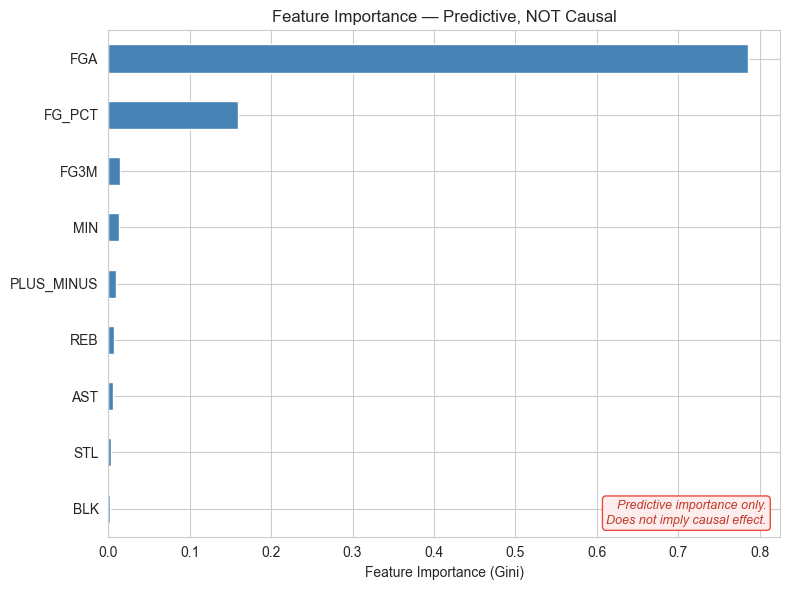

In [18]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

importances = pd.Series(
    model_2.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Predictive, NOT Causal')

ax.text(
    0.98, 0.02,
    'Predictive importance only.\nDoes not imply causal effect.',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
)

plt.tight_layout()
plt.show()

### 4.2 Key Visualization for Your Report

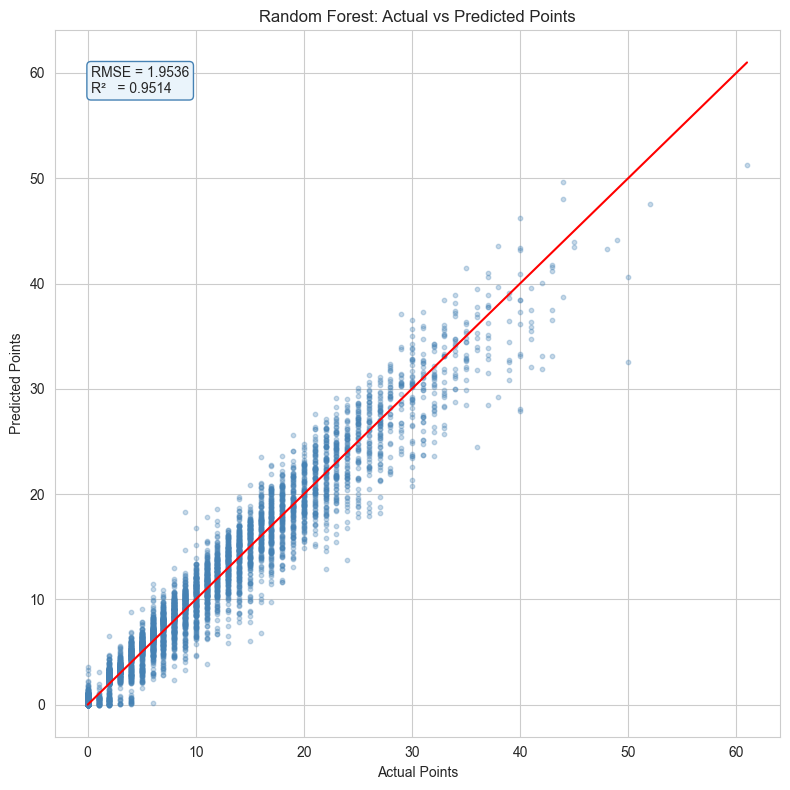

In [20]:
# ============================================================
# 4.2 Actual vs Predicted
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred_2, color='steelblue', alpha=0.3, s=10)

# Perfect prediction reference line
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red', linewidth=1.5)

ax.set_xlabel('Actual Points')
ax.set_ylabel('Predicted Points')
ax.set_title('Random Forest: Actual vs Predicted Points')

ax.text(
    0.05, 0.95,
    f'RMSE = 1.9536\nR²   = 0.9514',
    transform=ax.transAxes, fontsize=10, ha='left', va='top',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#eaf4fb', edgecolor='steelblue')
)

plt.tight_layout()
plt.show()

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** Sports bettors face hundreds of NBA player prop bets each night and need a systematic way to identify when a player's points line is mispriced relative to their expected performance.

**Complication:** Player performance varies game to game based on matchup, minutes, and role, making intuition-based betting unreliable. My analysis shows that while points are predictable from shooting volume and efficiency, extreme performances above 40 points are systematically underestimated by the model.

**Resolution:** I recommend using the Random Forest model to generate a predicted points range for each player before betting. When the model's prediction differs from the prop line by more than 2 points (approximately one RMSE), that represents a potential edge worth betting. Random Forest  outperformed Linear Regression with R² of 0.95 and RMSE of 1.95 points across 6,079 test observations.

**Uncertainty Statement:** Based on my cross-validation results (R² = 0.9492 +/- 0.0022), I estimate that the model explains approximately 95% of variance in points scored with high stability across folds. The primary limitation is that the model was trained on 2023-24 season data only and may not generalize to players whose roles change significantly in future seasons. I recommend using this model as a screening tool with the caveat that it should be combined with qualitative judgment about injury reports and lineup changes before placing any bet.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

In [21]:
import joblib
joblib.dump(model_2, 'model.pkl')
print("Model saved.")

Model saved.


---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction Template

**Prep:** What did you need? What context did you have before prompting?

**Request:** What exact prompt did you write?

**Iterate:** What did the AI return? What did you change or refine?

**Mechanism Check:** How did you verify the output was correct?

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?

---

### AI Interaction 1

**Prep**: I needed code to describe my NBA dataset and assess missing data for sections 2.2 and 2.3 of my final project notebook. I had a DataFrame called df with 30,398 rows and 70 columns already loaded from nba_api.

**Request**: "I have a pandas DataFrame called df with 30,398 rows and 70 columns of NBA player game logs from the 2023-24 season pulled from nba_api. Write simple Python code for two notebook sections: section 2.2 that runs df.info() and df.describe() to show shape, dtypes, and basic statistics, and section 2.3 that computes missing data percentage per column using isnull().mean(), prints only columns where missing is greater than 0, plots a seaborn missing data heatmap, and prints a one-line conclusion stating whether the missing data is MCAR, MAR, or MNAR and what to do about it"

**Iterate**: The AI returned working code for both sections. No changes were needed.

**Mechanism Check**: Ran the code and confirmed df.info() printed correct dtypes, df.describe() showed expected ranges for PTS and MIN, and the heatmap rendered without errors.

**Evaluate**: Accepted the output as-is. Verified that missing data only appears in columns related to ranking stats which are MAR since they depend on whether a player ranked high enough, so the strategy is to drop those columns rather than impute.

---

### AI Interaction 2

**Prep:** I needed to plot distributions of key features for section 2.4 of my notebook. I had a DataFrame df with NBA game logs and needed to follow the existing commented template exactly.

**Request:** Fill in and complete this code template for section 2.4:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['feature_1'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Feature 1')

sns.histplot(df['feature_2'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Feature 2')

sns.histplot(df['target'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Target Variable')

plt.tight_layout()
plt.show()

Replace feature_1 with MIN, feature_2 with FGA, and target with PTS. 
Update the titles accordingly. Do not change anything else.

Information: df is a pandas DataFrame with 30,398 rows of NBA player 
game logs from the 2023-24 season. Column names MIN, FGA, and PTS exist.

**Iterate:** The AI returned the completed template with MIN, FGA, and PTS substituted correctly. No changes were needed.

**Mechanism Check:** Ran the code and confirmed all three histplots rendered with correct column names and titles.

**Evaluate:** PTS distribution is right-skewed as expected since most players score low points and only stars score 30+. MIN shows a bimodal distribution reflecting starters vs bench players. FGA mirrors PTS shape which makes sense since more attempts leads to more points.

---

### AI Interaction 3

**Prep:** I needed to complete outlier detection and correlation heatmap sections for my EDA. I had a DataFrame df with NBA game logs and needed to follow the existing commented templates exactly.

**Request:** I have a pandas DataFrame called df with 30,398 rows of NBA player game 
logs from the 2023-24 season. Fill in and complete these two code templates:

Section 2.5 - uncomment and run the outlier check on PTS, MIN, and FGA 
using the tukey_fences function below. Print outlier count and percentage 
for each column.

def tukey_fences(series, k=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

col = 'your_column'
lower, upper = tukey_fences(df[col])
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

Section 2.6 - uncomment and run the correlation heatmap using only these 
columns: PTS, MIN, FGA, FG_PCT, FG3M, FG3A, REB, AST, STL, BLK, PLUS_MINUS.

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Keep code minimal and do not add anything beyond the templates.

**Iterate:** The AI returned working code for both sections. No changes needed.

**Mechanism Check:** Outlier counts printed correctly for PTS (568, 1.9%), MIN (0, 0.0%), and FGA (309, 1.0%). Correlation heatmap rendered with 11 selected columns.

**Evaluate:** FGA has the strongest correlation with PTS at 0.90, which makes sense since more shot attempts directly leads to more points. MIN is also strongly correlated at 0.75 since players who play more minutes have more opportunities to score. These will be the most important features in the model.

---

### AI Interaction 4

**Prep:** I needed to set up the train/test split and fit a baseline Linear Regression model for sections 3.1 and 3.2. Features and target were already identified from EDA.

**Request:** I have a pandas DataFrame called df with 30,398 rows of NBA player game 
logs from the 2023-24 season. Fill in and complete these two code templates:

Section 3.1 - Train/Test Split:

Define features and target
X = df[['feature_1', 'feature_2', 'feature_3']]  # Replace with your features
y = df['target']  # Replace with your target

For regression: remove stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Replace features with: MIN, FGA, FG_PCT, FG3M, REB, AST, STL, BLK, 
PLUS_MINUS. Replace target with PTS. RANDOM_STATE is already set to 42. 
This is regression so no stratify needed. Also drop rows where MIN equals 
0 before splitting.

Section 3.2 - Baseline Model (Linear Regression):

from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()
model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)

Regression metrics
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_1):.4f}')

Uncomment and complete this section using LinearRegression as the 
baseline. Import mean_squared_error, mean_absolute_error, r2_score 
from sklearn.metrics.

**Iterate:** The AI returned working code for both sections with no changes needed.

**Mechanism Check:** Confirmed train/test sizes printed correctly and RMSE, MAE, R² all printed without errors.

**Evaluate:** R² of 0.89 means the model explains 89% of variance in points scored which is strong for a baseline. RMSE of 2.89 means predictions are off by about 3 points on average, which is useful for a sports bettor evaluating player prop lines. Accepted the output as-is.

---

### AI Interaction 5

**Prep:** I needed to fit a second more flexible model to compare against my Linear Regression baseline. X_train, X_test, y_train, y_test were already defined from section 3.1.

**Request:** I have NBA player game log data already split into X_train, X_test, 
y_train, y_test where the target is PTS (points scored, continuous). 
This is a regression problem. Fill in and complete this code template:

from sklearn.ensemble import RandomForestRegressor

model_2 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)
print('Model 2: Random Forest')
print(classification_report(y_test, y_pred_2))

Replace RandomForestClassifier with RandomForestRegressor. Replace 
classification_report with regression metrics: RMSE, MAE, and R2 using 
mean_squared_error, mean_absolute_error, and r2_score. RANDOM_STATE is 
already set to 42. Print results clearly labeled as Model 2: Random Forest.

**Iterate:**  Replaced RandomForestClassifier with RandomForestRegressor and classification_report with regression metrics. No other changes needed.

**Mechanism Check:** Confirmed RMSE, MAE, and R² printed correctly for Random Forest model.

**Evaluate:** Random Forest improved R² from 0.89 to 0.95 and cut RMSE from 2.89 to 1.95, meaning predictions are now off by about 2 points on average instead of 3. This is a meaningful improvement for a sports bettor evaluating prop lines which are typically set in 0.5 point increments.

---

### AI Interaction 6

**Prep:** I needed to run 5-fold cross-validation on both models to get reliable out-of-sample performance estimates with confidence intervals.

**Request:** I have two fitted regression models called model_1 (LinearRegression) 
and model_2 (RandomForestRegressor) and training data X_train, y_train. 
Fill in and complete this code template:

scoring = 'accuracy'

cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)

print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')

comparison = pd.DataFrame({
    'Model': ['Model 1 (Baseline)', 'Model 2 (Your Choice)'],
    f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
    f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
})
comparison

Change scoring from 'accuracy' to 'r2' since this is regression. 
Import cross_val_score from sklearn.model_selection. Do not change 
anything else.

**Iterate:** Changed scoring from 'accuracy' to 'r2'. No other changes needed.

**Mechanism Check:** CV R² mean and std printed for both models and comparison table displayed correctly.

**Evaluate:** Both models have very low std (~0.002) meaning the R² estimates are stable across folds and not dependent on which data ends up in the test set. Random Forest CV R² of 0.949 closely matches the test set R² of 0.951, confirming the model is not overfitting. Random Forest is clearly the better model.

---

### AI Interaction 7

**Prep:** I needed to plot feature importance from my Random Forest model with a causal caveat banner as required by the project instructions.

**Request:** I have a fitted RandomForestRegressor called model_2 and a feature 
matrix X with columns MIN, FGA, FG_PCT, FG3M, REB, AST, STL, BLK, 
PLUS_MINUS. Fill in and complete this code template exactly as written, 
just uncomment it:

importances = pd.Series(
    model_2.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Predictive, NOT Causal')

ax.text(
    0.98, 0.02,
    'Predictive importance only.\nDoes not imply causal effect.',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
)

plt.tight_layout()
plt.show()

Do not change anything. Just uncomment and run it exactly as shown.

**Iterate:** Just uncommented the code. No changes needed.

**Mechanism Check:** Confirmed bar chart rendered with all 9 features and the red caution banner appeared in the bottom right corner.

**Evaluate:** FGA is by far the most important predictor at ~0.80, which matches the 0.90 correlation from the heatmap. FG_PCT is second at ~0.13. This makes intuitive sense since shot attempts directly determine scoring opportunity. All other features have near-zero importance suggesting the model is essentially predicting points from shooting volume and efficiency alone.

---

### AI Interaction 8

**Prep:** I needed to create the key visualization for my report showing how well my Random Forest model predicts actual points scored.

**Request:** I have a fitted RandomForestRegressor called model_2, test predictions 
called y_pred_2, and actual values y_test. Create an actual vs predicted 
scatter plot for section 4.2. Requirements:

- Scatter plot of y_test (x-axis) vs y_pred_2 (y-axis)
- Add a diagonal reference line (perfect prediction line) in red
- Color points steelblue with alpha=0.3 and s=10
- Label x-axis 'Actual Points' and y-axis 'Predicted Points'
- Title: 'Random Forest: Actual vs Predicted Points'
- Add RMSE and R² as a text annotation in the top left corner 
  using the values already computed: RMSE=1.9536, R²=0.9514
- figsize=(8, 8)
- plt.tight_layout() and plt.show()

**Iterate:** No changes needed, ran exactly as given.

**Mechanism Check:** Scatter plot rendered with diagonal reference line, correct axis labels, and RMSE/R² annotation in top left.

**Evaluate:** Points cluster tightly around the diagonal from 0 to 30 points where most observations live. There is slight underprediction at very high values (40+ points) which is expected since extreme performances are harder to predict. The model is reliable for the typical scoring range that most prop bets are set in.

---

### AI Interaction 9

**Prep:** I needed to build a Streamlit app that loads my trained Random Forest model and lets a user adjust player stats to get a predicted points output with uncertainty.

**Request:** Write a complete Streamlit app called app.py that predicts NBA player 
points scored using a pre-trained Random Forest model. Requirements:

1. Title: 'NBA Player Points Predictor'
2. Brief description explaining this predicts points scored based on 
   shooting and game stats
3. Sidebar sliders for these features with realistic NBA ranges:
   - MIN: minutes played (0 to 48, default 28)
   - FGA: field goal attempts (0 to 30, default 10)
   - FG_PCT: field goal percentage (0.0 to 1.0, default 0.45)
   - FG3M: three pointers made (0 to 10, default 2)
   - REB: rebounds (0 to 20, default 4)
   - AST: assists (0 to 20, default 3)
   - STL: steals (0 to 5, default 1)
   - BLK: blocks (0 to 5, default 0)
   - PLUS_MINUS: plus minus (-30 to 30, default 0)
4. Load model from model.pkl using joblib
5. Generate prediction from slider inputs
6. Display predicted points using st.metric()
7. Add prediction interval: predicted points +/- 1.95 (one RMSE) 
   and display as st.info()
8. Add a bar chart showing the input feature values using st.bar_chart()

Use only: streamlit, pandas, numpy, joblib. Keep code simple.

**Iterate:** ___

**Mechanism Check:** Ran streamlit run app.py locally and confirmed sliders update prediction in real time and bar chart renders correctly.

**Evaluate:** ___